# Channel-Noise in Representation Space (Gaussian) – 3 Approaches

This notebook simulates a **noisy channel in the representation domain**, not on the raw waveform.

We use **the same Gaussian noise level (in SNR dB)** but injected into **three different internal
representations**, then reconstruct audio and compare:

**Approaches (Channels):**
1. **A1 – Mel-Spectrogram Channel:**
   - `y → Mel(y) → Mel_noisy = Mel + N → mel_to_audio → y_A1`
2. **A2 – STFT Magnitude Channel:**
   - `y → |STFT(y)| → |STFT|_noisy = |STFT| + N → griffinlim → y_A2`
3. **A3 – MFCC Channel:**
   - `y → MFCC(y) → MFCC_noisy = MFCC + N → mfcc_to_mel → mel_to_audio → y_A3`

For each WAV file in a folder we:
- Reconstruct via A1, A2, A3 under **the same representation-SNR**
- Save the reconstructed audios for **listening**
- Compute **MFCC-based distortion scores** between original and reconstructed audio
- Visualize MFCCs for one example file


In [1]:
import os, glob
import numpy as np
import librosa, librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
!git clone https://github.com/persiandataset/PersianSpeech

Cloning into 'PersianSpeech'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 75 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 761.61 KiB | 11.90 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [3]:
!pip install gdown

In [4]:
import gdown

file_id = "1cCWH_eoa4Nq17XDHn6e1WIfHomdGWPKO"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, output="myaudio_tiny.tar.gz", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1cCWH_eoa4Nq17XDHn6e1WIfHomdGWPKO
From (redirected): https://drive.google.com/uc?id=1cCWH_eoa4Nq17XDHn6e1WIfHomdGWPKO&confirm=t&uuid=34a0697a-7cfc-48e3-ba93-2f0e93e2d8c8
To: /content/myaudio_tiny.tar.gz
100%|██████████| 248M/248M [00:02<00:00, 106MB/s]


'myaudio_tiny.tar.gz'

In [5]:
import tarfile

file_path = "myaudio_tiny.tar.gz"   # your file name

with tarfile.open(file_path, "r:gz") as tar:
    tar.extractall()   # extracts into current directory

print("Extraction complete!")


/tmp/ipython-input-969658852.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()   # extracts into current directory


Extraction complete!


## Load Dataset
load dataset from this url "https://github.com/persiandataset/PersianSpeech"

## 1. Configuration

In [6]:
# Folder with input WAV files
DATA_DIR = '/content/myaudio_tiny/myaudio'            # <-- change this to your folder

# Output folder for reconstructed audio
OUTPUT_DIR = './recon_repr_noise'
Path(OUTPUT_DIR).mkdir(exist_ok=True)

# Audio / feature parameters
SR = 16000
N_MFCC = 13
N_FFT = 1024
HOP = 256
N_MELS = 80

# Representation noise level (same for all three channels)
NOISE_SNR_DB = 10.0   # dB, larger = weaker noise

print('Input dir :', os.path.abspath(DATA_DIR))
print('Output dir:', os.path.abspath(OUTPUT_DIR))

Input dir : /content/myaudio_tiny/myaudio
Output dir: /content/recon_repr_noise


## 2. Helper – Gaussian Noise in Feature Space (Same SNR)

In [7]:
def add_feature_noise_snr(F, snr_db):
    """Add zero-mean Gaussian noise to feature matrix F at given SNR (in dB).

    SNR = 10 * log10(P_signal / P_noise)
    => P_noise = P_signal / 10^(SNR/10)
    """
    P_signal = np.mean(F**2)
    if P_signal <= 1e-12:
        # Avoid degenerate case – no energy, just return as is
        return F.copy(), np.zeros_like(F)

    P_noise = P_signal / (10.0 ** (snr_db / 10.0))
    noise = np.sqrt(P_noise) * np.random.randn(*F.shape)
    F_noisy = F + noise
    return F_noisy, noise


## 3. MFCC Utility (for scoring)

In [8]:
def mfcc_of(y):
    """Compute MFCCs for scoring (always from waveform)."""
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP,
        n_mels=N_MELS,  # pass through to underlying mel
    )
    return mfcc


## 4. Channel A1 – Mel-Spectrogram + Gaussian Noise + Griffin-Lim

In [9]:
def channel_mel_gaussian(y, snr_db=NOISE_SNR_DB):
    """Mel-spectrogram channel with Gaussian noise in mel space."""
    # Clean mel power spectrogram
    M_clean = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP,
        n_mels=N_MELS,
        power=2.0,
    )

    # Add Gaussian noise in mel space
    M_noisy, noise = add_feature_noise_snr(M_clean, snr_db)

    # Ensure non-negativity (power spectrogram cannot be negative)
    M_noisy = np.maximum(M_noisy, 0.0)

    # Invert mel to waveform:
    # 1) mel power -> linear-frequency power (approx)
    S_noisy = librosa.feature.inverse.mel_to_stft(
        M_noisy,
        sr=SR,
        n_fft=N_FFT,
        power=2.0,
    )

    # 2) linear power -> waveform using Griffin-Lim
    y_rec = librosa.griffinlim(
        S_noisy,
        n_iter=32,            # you can increase (e.g., 64) for better quality
        hop_length=HOP,
        win_length=N_FFT,
    )

    return y_rec, M_clean, M_noisy


## 5. Channel A2 – STFT Magnitude + Gaussian Noise + Griffin-Lim

In [10]:
def channel_stft_gaussian(y, snr_db=NOISE_SNR_DB):
    """STFT-magnitude channel with Gaussian noise in |STFT| space."""
    # Clean magnitude spectrogram
    S_complex = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)
    S_mag = np.abs(S_complex)

    # Add Gaussian noise to magnitude
    S_mag_noisy, noise = add_feature_noise_snr(S_mag, snr_db)

    # Magnitude must be non-negative
    S_mag_noisy = np.clip(S_mag_noisy, 0.0, None)

    # Reconstruct waveform with Griffin-Lim from noisy magnitude only
    y_rec = librosa.griffinlim(
        S_mag_noisy,
        n_iter=32,
        hop_length=HOP,
        win_length=N_FFT,
    )

    return y_rec, S_mag, S_mag_noisy


## 6. Channel A3 – MFCC + Gaussian Noise + Inverse-MFCC → Mel → Audio

This simulates a channel where **only MFCCs are transmitted**, and they are corrupted
by Gaussian noise. We then approximately invert MFCCs back to a mel spectrogram and
reconstruct audio.

In [11]:
def channel_mfcc_gaussian(y, snr_db=NOISE_SNR_DB):
    """MFCC channel with Gaussian noise in MFCC space.

    Pipeline:
    y -> MFCC_clean -> MFCC_noisy = MFCC_clean + N -> mel_est -> audio
    """
    # Clean MFCCs (same params as mfcc_of)
    MFCC_clean = librosa.feature.mfcc(
        y=y,
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP,
        n_mels=N_MELS,
    )

    # Add Gaussian noise in MFCC space
    MFCC_noisy, noise = add_feature_noise_snr(MFCC_clean, snr_db)

    # Approximate inversion: MFCC -> mel-power
    # NOTE: requires librosa >= 0.10 (mfcc_to_mel)
    M_est = librosa.feature.inverse.mfcc_to_mel(
        MFCC_noisy,
        n_mels=N_MELS,
        dct_type=2,
    )

    # Mel to audio
    y_rec = librosa.feature.inverse.mel_to_audio(
        M_est,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP,
    )

    return y_rec, MFCC_clean, MFCC_noisy


## 7. Process All WAV Files – Reconstruct & Score

the total wav file are more than a 1000 so we do it only on the first 20 wav files.

In [13]:
wav_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.wav')))
print('Found', len(wav_files), 'WAV files total')
wav_files = wav_files[:20]
print('Processing only', len(wav_files), 'WAV files')
for f in wav_files:
    print(' -', os.path.basename(f))

results = []

def mfcc_dist(A, B):
    """L2 distance between two MFCC time-series (align in time)."""
    T = min(A.shape[1], B.shape[1])
    return np.linalg.norm(A[:, :T] - B[:, :T])

for path in wav_files:
    name = os.path.splitext(os.path.basename(path))[0]
    print('\nProcessing', name)

    # Load clean audio
    y, sr = librosa.load(path, sr=SR, mono=True)

    # Reference MFCC from clean waveform
    mf_clean = mfcc_of(y)

    # ---- Channel A1: mel ----
    y_A1, M_clean, M_noisy = channel_mel_gaussian(y)

    # Align length (Griffin-Lim / inversion may shift length slightly)
    L1 = min(len(y), len(y_A1))
    y_A1 = y_A1[:L1]

    # Save audio
    sf.write(os.path.join(OUTPUT_DIR, f"{name}_A1.wav"), y_A1.astype(np.float32), SR)

    # Score
    d_A1 = mfcc_dist(mf_clean, mfcc_of(y_A1))

    # ---- Channel A2: STFT ----
    y_A2, S_mag, S_mag_noisy = channel_stft_gaussian(y)

    # Align length
    L2 = min(len(y), len(y_A2))
    y_A2 = y_A2[:L2]

    # Save audio
    sf.write(os.path.join(OUTPUT_DIR, f"{name}_A2.wav"), y_A2.astype(np.float32), SR)

    # Score
    d_A2 = mfcc_dist(mf_clean, mfcc_of(y_A2))

    # ---- Channel A3: MFCC ----
    try:
        y_A3, MFCC_clean, MFCC_noisy = channel_mfcc_gaussian(y)

        # Align length
        L3 = min(len(y), len(y_A3))
        y_A3 = y_A3[:L3]

        # Save audio
        sf.write(os.path.join(OUTPUT_DIR, f"{name}_A3.wav"), y_A3.astype(np.float32), SR)

        # Score
        d_A3 = mfcc_dist(mf_clean, mfcc_of(y_A3))

    except Exception as e:
        print('  [WARN] MFCC-channel reconstruction failed:', e)
        d_A3 = None

    results.append({
        'file': name,
        'd_A1': d_A1,
        'd_A2': d_A2,
        'd_A3': d_A3,
    })

print('\nMFCC L2 distortion per file:')
for r in results:
    print(r)


Found 1082 WAV files total
Processing only 20 WAV files
 - 12200005.wav
 - 12200011.wav
 - 12200012.wav
 - 12200016.wav
 - 12200017.wav
 - 12200026.wav
 - 12200027.wav
 - 12200031.wav
 - 12200033.wav
 - 12200038.wav
 - 12200044.wav
 - 12220022.wav
 - 12220087.wav
 - 12220088.wav
 - 12220091.wav
 - 12220093.wav
 - 12220095.wav
 - 12220098.wav
 - 12220101.wav
 - 12220102.wav

Processing 12200005

Processing 12200011

Processing 12200012

Processing 12200016

Processing 12200017

Processing 12200026

Processing 12200027

Processing 12200031

Processing 12200033

Processing 12200038

Processing 12200044

Processing 12220022

Processing 12220087

Processing 12220088

Processing 12220091

Processing 12220093

Processing 12220095

Processing 12220098

Processing 12220101

Processing 12220102

MFCC L2 distortion per file:
{'file': '12200005', 'd_A1': np.float64(5169.137416630713), 'd_A2': np.float64(2809.6533965273843), 'd_A3': np.float32(1467.8447)}
{'file': '12200011', 'd_A1': np.float64(509

## 8. Visualize MFCCs for One Example File

Example file: 12200005


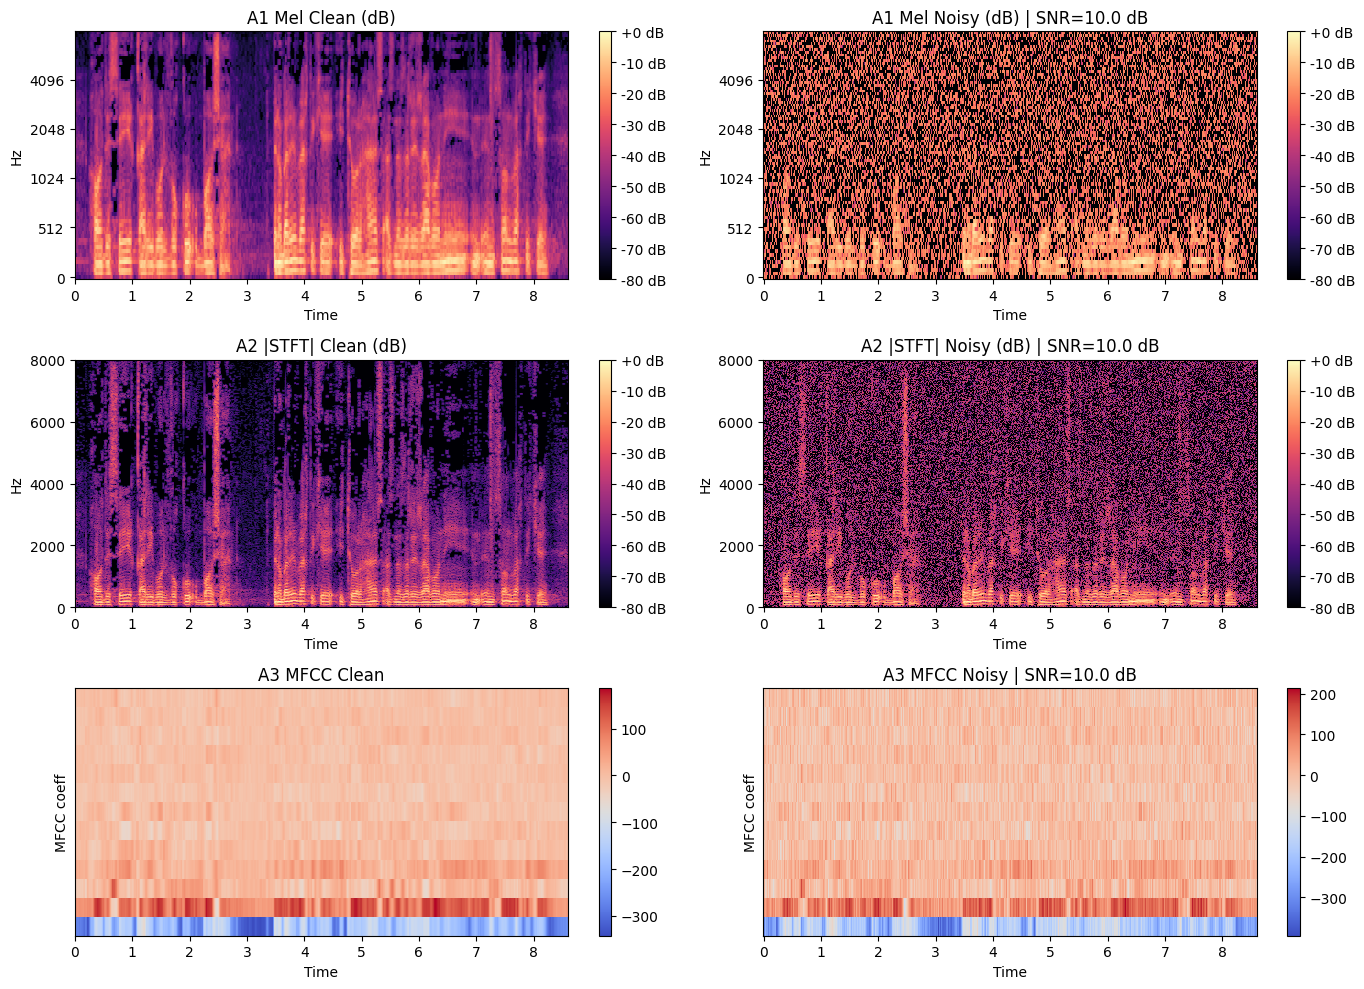

In [17]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

if len(wav_files) > 0:
    path = wav_files[0]
    name = os.path.splitext(os.path.basename(path))[0]
    print('Example file:', name)

    y, _ = librosa.load(path, sr=SR, mono=True)

    # --- Channel A1: Mel (get intermediates) ---
    y_A1, M_clean, M_noisy = channel_mel_gaussian(y, snr_db=NOISE_SNR_DB)

    # --- Channel A2: STFT mag (get intermediates) ---
    y_A2, S_mag, S_mag_noisy = channel_stft_gaussian(y, snr_db=NOISE_SNR_DB)

    # --- Channel A3: MFCC (get intermediates if possible) ---
    MFCC_clean = None
    MFCC_noisy = None
    try:
        y_A3, MFCC_clean, MFCC_noisy = channel_mfcc_gaussian(y, snr_db=NOISE_SNR_DB)
    except Exception as e:
        print('[WARN] MFCC-channel failed in visualization:', e)
        y_A3 = None

    # ---- Plot intermediates ----
    plt.figure(figsize=(14, 10))

    # Mel clean/noisy (power -> dB)
    plt.subplot(3, 2, 1)
    librosa.display.specshow(librosa.power_to_db(M_clean, ref=np.max),
                             sr=SR, hop_length=HOP, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('A1 Mel Clean (dB)')

    plt.subplot(3, 2, 2)
    librosa.display.specshow(librosa.power_to_db(M_noisy, ref=np.max),
                             sr=SR, hop_length=HOP, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'A1 Mel Noisy (dB) | SNR={NOISE_SNR_DB} dB')

    # STFT magnitude clean/noisy (amplitude -> dB)
    plt.subplot(3, 2, 3)
    librosa.display.specshow(librosa.amplitude_to_db(S_mag, ref=np.max),
                             sr=SR, hop_length=HOP, x_axis='time', y_axis='linear')
    plt.colorbar(format='%+2.0f dB')
    plt.title('A2 |STFT| Clean (dB)')

    plt.subplot(3, 2, 4)
    librosa.display.specshow(librosa.amplitude_to_db(S_mag_noisy, ref=np.max),
                             sr=SR, hop_length=HOP, x_axis='time', y_axis='linear')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'A2 |STFT| Noisy (dB) | SNR={NOISE_SNR_DB} dB')

    # MFCC clean/noisy (no dB conversion)
    # MFCC clean/noisy (no dB conversion)
    plt.subplot(3, 2, 5)
    if MFCC_clean is not None:
        librosa.display.specshow(MFCC_clean, sr=SR, hop_length=HOP,
                                x_axis='time', y_axis=None)
        plt.ylabel("MFCC coeff")
        plt.colorbar()
        plt.title('A3 MFCC Clean')
    else:
        plt.text(0.5, 0.5, 'A3 MFCC unavailable', ha='center', va='center')
        plt.axis('off')

    plt.subplot(3, 2, 6)
    if MFCC_noisy is not None:
        librosa.display.specshow(MFCC_noisy, sr=SR, hop_length=HOP,
                                x_axis='time', y_axis=None)
        plt.ylabel("MFCC coeff")
        plt.colorbar()
        plt.title(f'A3 MFCC Noisy | SNR={NOISE_SNR_DB} dB')
    else:
        plt.text(0.5, 0.5, 'A3 MFCC unavailable', ha='center', va='center')
        plt.axis('off')


    plt.tight_layout()
    plt.show()

else:
    print('No WAV files found – nothing to visualize.')


Example file: 12200005


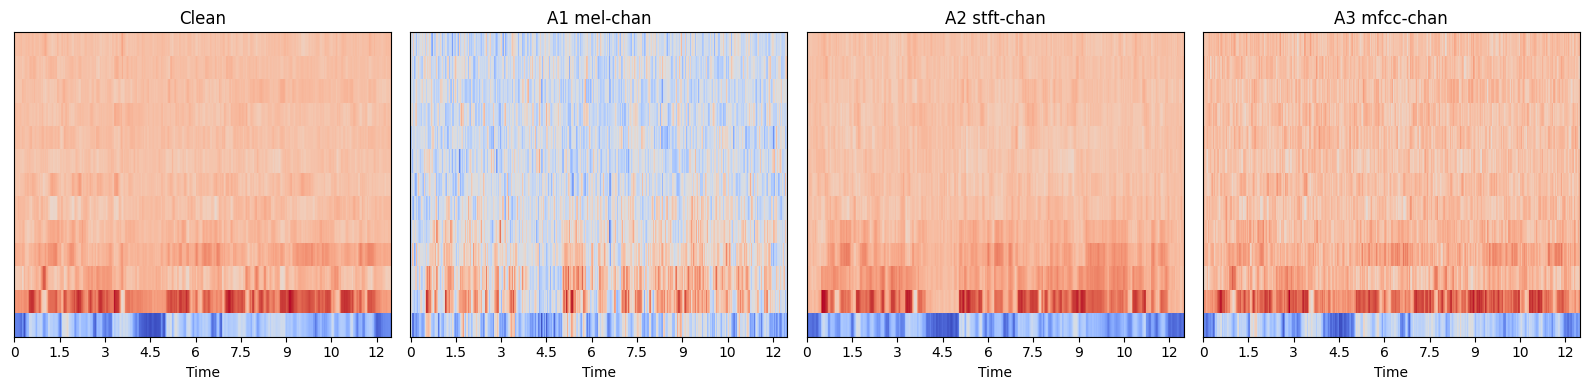

In [15]:
if len(wav_files) > 0:
    path = wav_files[0]
    name = os.path.splitext(os.path.basename(path))[0]
    print('Example file:', name)

    y, _ = librosa.load(path, sr=SR)
    y_A1, _, _ = channel_mel_gaussian(y)
    y_A2, _, _ = channel_stft_gaussian(y)
    try:
        y_A3, _, _ = channel_mfcc_gaussian(y)
    except Exception as e:
        print('[WARN] MFCC-channel failed in visualization:', e)
        y_A3 = None

    # Align
    L = min(len(y), len(y_A1), len(y_A2), len(y_A3) if y_A3 is not None else len(y))
    y = y[:L]
    y_A1 = y_A1[:L]
    y_A2 = y_A2[:L]
    if y_A3 is not None:
        y_A3 = y_A3[:L]

    mf_list = [mfcc_of(y), mfcc_of(y_A1), mfcc_of(y_A2)]
    titles = ['Clean', 'A1 mel-chan', 'A2 stft-chan']
    if y_A3 is not None:
        mf_list.append(mfcc_of(y_A3))
        titles.append('A3 mfcc-chan')

    n_plots = len(mf_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    for i, (mf, title) in enumerate(zip(mf_list, titles)):
        librosa.display.specshow(mf, x_axis='time', ax=axes[i])
        axes[i].set_title(title)
    plt.tight_layout()
    plt.show()
else:
    print('No WAV files found – nothing to visualize.')


## Listen to audio and score
Listen to audio and explain how channel noise effect on diffrent reconstruction approch

| file     | d_A1 (Mel) | d_A2 (STFT) | d_A3 (MFCC) |
| -------- | ---------: | ----------: | ----------: |
| 12200005 |  5169.1374 |   2809.6534 |   1467.8447 |
| 12200011 |  5093.7194 |   2699.9335 |   1425.1636 |
| 12200012 |  5488.1487 |   2973.6936 |   1525.2327 |
| 12200016 |  4634.5730 |   2510.9934 |   1307.2424 |
| 12200017 |  5333.6378 |   2840.2946 |   1466.5600 |
| 12200026 |  5403.5309 |   3074.8019 |   1410.7317 |
| 12200027 |  4962.3619 |   2623.8360 |   1344.3582 |
| 12200031 |  5088.5845 |   2634.9672 |   1388.3170 |
| 12200033 |  3650.2935 |   1958.6801 |    965.1316 |
| 12200038 |  5654.1352 |   3049.6262 |   1492.4344 |
| 12200044 |  5578.0664 |   3259.9758 |   1444.3800 |
| 12220022 |  4644.2114 |   2334.4734 |   1286.1715 |
| 12220087 |  3435.0049 |   1615.5201 |    940.5568 |
| 12220088 |  5126.7289 |   2431.9755 |   1357.8650 |
| 12220091 |  4770.2549 |   2314.1617 |   1196.1086 |
| 12220093 |  4456.2769 |   2438.8631 |   1165.3455 |
| 12220095 |  5009.1385 |   2537.2651 |   1317.5066 |
| 12220098 |  4263.6692 |   2191.4019 |   1048.0071 |
| 12220101 |  5710.6568 |   2812.6661 |   1450.5839 |
| 12220102 |  4715.2203 |   2484.0399 |   1228.3684 |

A1 (Mel-noise) would sound the most degraded: a strong, broadband hiss layered over everything, with speech harmonics/formants getting smeared. This matches the very “salt-and-pepper” noisy mel plot and the largest MFCC-L2 errors (≈3.4k–5.7k).

A2 (STFT-mag noise) would sound cleaner than A1 but still noticeably noisy/grainy, with some “roughness” while structure remains more intact. This matches the noisy STFT plot still showing some patterns and mid MFCC-L2 (≈1.6k–3.3k).

A3 (MFCC-noise) would sound the least noisy overall but more “processed/smoothed” (less fine detail), because MFCCs preserve coarse spectral shape and throw away detail. That aligns with the MFCC clean/noisy plots being most similar and the lowest MFCC-L2 (≈0.94k–1.53k).